# Análises finais

As perguntas são respondidas a partir de `workspace.gold.partidas_analiticas`. Os resultados mostram associação, não causalidade.

In [0]:
from pyspark.sql import functions as F
from pyspark.sql import Window
import matplotlib.pyplot as plt

partidas = spark.table("workspace.gold.partidas_analiticas")
viradas = spark.table("workspace.gold.viradas")

cores = ["#2563eb", "#94a3b8", "#f97316"]

## 1. Times mandantes vencem mais?

resultado,count,percentual
mandante,4550,49.6
empate,2421,26.4
visitante,2194,23.9


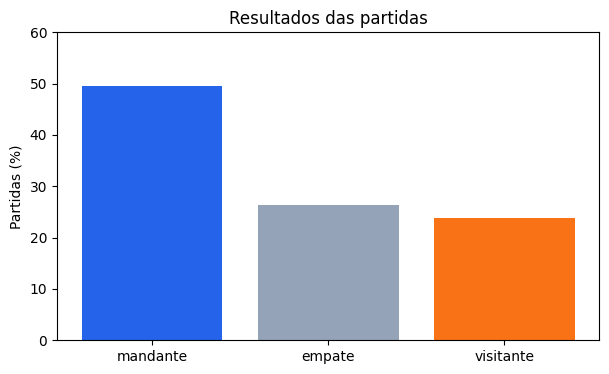

Mandantes venceram 49.6% das partidas; visitantes, 23.9%.


In [0]:
mando = (
    partidas.groupBy("resultado").count()
    .withColumn("percentual", F.round(100 * F.col("count") / partidas.count(), 1))
    .orderBy(F.desc("count"))
)

display(mando)

mando_pd = mando.toPandas()
plt.figure(figsize=(7, 4))
plt.bar(mando_pd["resultado"], mando_pd["percentual"], color=cores)
plt.title("Resultados das partidas")
plt.ylabel("Partidas (%)")
plt.ylim(0, 60)
plt.show()

taxa_mandante = mando.filter("resultado = 'mandante'").first()["percentual"]
taxa_visitante = mando.filter("resultado = 'visitante'").first()["percentual"]
print(f"Mandantes venceram {taxa_mandante}% das partidas; visitantes, {taxa_visitante}%.")

## 2 e 3. Maior posse ou mais escanteios significam mais vitórias?

desfecho,count,metrica,percentual
Derrota,1517,Maior posse,40.3
Empate,1007,Maior posse,26.7
Vitória,1244,Maior posse,33.0
Derrota,1306,Mais escanteios,37.8
Empate,919,Mais escanteios,26.6
Vitória,1233,Mais escanteios,35.7


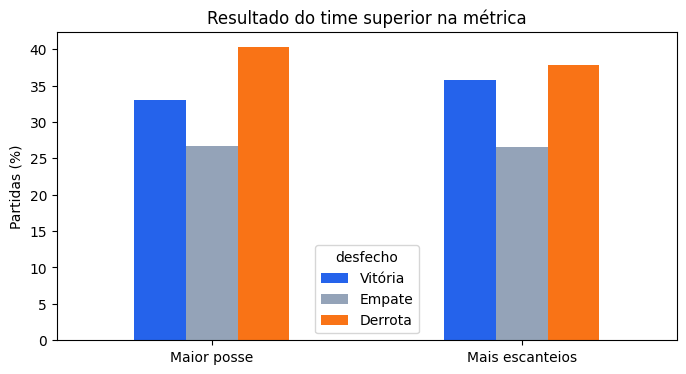

Maior posse: 33.0% de vitórias e 40.3% de derrotas.
Mais escanteios: 35.7% de vitórias e 37.8% de derrotas.


In [0]:
def resultado_da_metrica(coluna_mandante, coluna_visitante, nome):
    lado = (
        F.when(F.col(coluna_mandante) > F.col(coluna_visitante), "mandante")
         .when(F.col(coluna_visitante) > F.col(coluna_mandante), "visitante")
    )

    return (
        partidas.withColumn("lado_maior", lado)
        .filter("lado_maior IS NOT NULL")
        .withColumn(
            "desfecho",
            F.when(F.col("resultado") == "empate", "Empate")
             .when(F.col("resultado") == F.col("lado_maior"), "Vitória")
             .otherwise("Derrota")
        )
        .groupBy("desfecho").count()
        .withColumn("metrica", F.lit(nome))
    )

posse = resultado_da_metrica("posse_mandante", "posse_visitante", "Maior posse")
escanteios = resultado_da_metrica("escanteios_mandante", "escanteios_visitante", "Mais escanteios")

metricas = posse.unionByName(escanteios)
janela = Window.partitionBy("metrica")
metricas = metricas.withColumn("percentual", F.round(100 * F.col("count") / F.sum("count").over(janela), 1))

display(metricas.orderBy("metrica", "desfecho"))

metricas_pd = metricas.toPandas().pivot(index="metrica", columns="desfecho", values="percentual")
metricas_pd = metricas_pd.reindex(columns=["Vitória", "Empate", "Derrota"])
metricas_pd.plot(kind="bar", figsize=(8, 4), color=["#2563eb", "#94a3b8", "#f97316"])
plt.title("Resultado do time superior na métrica")
plt.ylabel("Partidas (%)")
plt.xlabel("")
plt.xticks(rotation=0)
plt.show()

for metrica in ["Maior posse", "Mais escanteios"]:
    valores = metricas.filter(F.col("metrica") == metrica).select("desfecho", "percentual").collect()
    taxas = {linha["desfecho"]: linha["percentual"] for linha in valores}
    print(f"{metrica}: {taxas['Vitória']}% de vitórias e {taxas['Derrota']}% de derrotas.")

## 4. Quem marca o primeiro gol vence mais?

desfecho,count,percentual
Vitória,2925,70.1
Empate,828,19.9
Derrota com virada,418,10.0


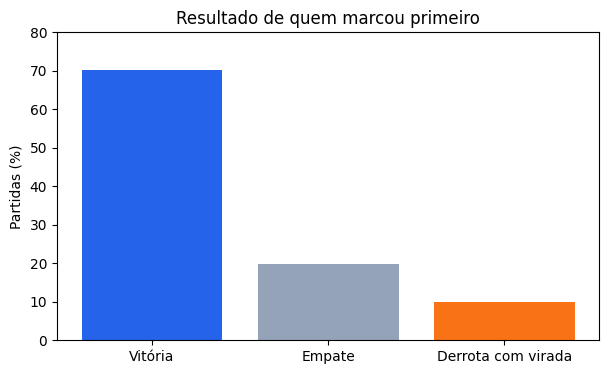

Quem marcou primeiro venceu 70.1% das partidas elegíveis.


In [0]:
primeiro_gol = (
    partidas.filter("primeiro_clube IS NOT NULL AND NOT primeiro_gol_ambiguo")
    .withColumn(
        "desfecho",
        F.when(F.col("primeiro_gol_venceu"), "Vitória")
         .when(F.col("resultado") == "empate", "Empate")
         .otherwise("Derrota com virada")
    )
    .groupBy("desfecho").count()
)

total_primeiro_gol = primeiro_gol.agg(F.sum("count")).first()[0]
primeiro_gol = primeiro_gol.withColumn(
    "percentual", F.round(100 * F.col("count") / F.lit(total_primeiro_gol), 1)
)

display(primeiro_gol.orderBy(F.desc("count")))

primeiro_pd = primeiro_gol.orderBy(F.desc("count")).toPandas()
plt.figure(figsize=(7, 4))
plt.bar(primeiro_pd["desfecho"], primeiro_pd["percentual"], color=cores)
plt.title("Resultado de quem marcou primeiro")
plt.ylabel("Partidas (%)")
plt.ylim(0, 80)
plt.show()

taxa_primeiro = primeiro_gol.filter("desfecho = 'Vitória'").first()["percentual"]
print(f"Quem marcou primeiro venceu {taxa_primeiro}% das partidas elegíveis.")

## 5. Qual é o time da virada do Rio?

clube,vezes_que_sofreu_primeiro,viradas,taxa_virada_pct
Flamengo,165,29,17.6
Fluminense,200,23,11.5
Botafogo-RJ,173,15,8.7
Vasco,151,10,6.6


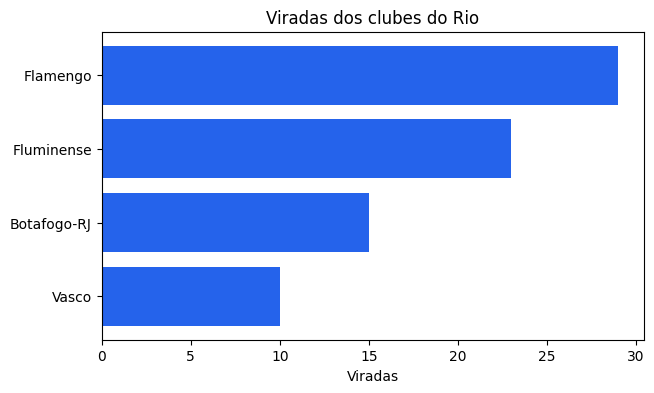

Flamengo lidera com 29 viradas (17.6%).
Vasco: 10 viradas (6.6%).


In [0]:
com_primeiro_gol = partidas.filter("primeiro_clube IS NOT NULL AND NOT primeiro_gol_ambiguo")

oportunidades_rj = (
    com_primeiro_gol
    .withColumn(
        "clube_que_sofreu_primeiro",
        F.when(F.col("primeiro_clube") == F.col("mandante"), F.col("visitante"))
         .otherwise(F.col("mandante"))
    )
    .withColumn(
        "estado_clube",
        F.when(F.col("primeiro_clube") == F.col("mandante"), F.col("estado_visitante"))
         .otherwise(F.col("estado_mandante"))
    )
    .filter("estado_clube = 'RJ'")
    .groupBy("clube_que_sofreu_primeiro")
    .count()
    .withColumnRenamed("clube_que_sofreu_primeiro", "clube")
    .withColumnRenamed("count", "vezes_que_sofreu_primeiro")
)

viradas_rj = (
    viradas.filter("estado_vencedor = 'RJ'")
    .groupBy(F.col("vencedor").alias("clube"))
    .count()
    .withColumnRenamed("count", "viradas")
)

ranking_viradas = (
    oportunidades_rj.join(viradas_rj, "clube", "left")
    .fillna(0, ["viradas"])
    .withColumn("taxa_virada_pct", F.round(100 * F.col("viradas") / F.col("vezes_que_sofreu_primeiro"), 1))
    .orderBy(F.desc("viradas"), F.desc("taxa_virada_pct"))
)

display(ranking_viradas)

viradas_pd = ranking_viradas.toPandas().sort_values("viradas")
plt.figure(figsize=(7, 4))
plt.barh(viradas_pd["clube"], viradas_pd["viradas"], color="#2563eb")
plt.title("Viradas dos clubes do Rio")
plt.xlabel("Viradas")
plt.show()

lider = ranking_viradas.first()
vasco = ranking_viradas.filter("clube = 'Vasco'").first()
print(f"{lider['clube']} lidera com {lider['viradas']} viradas ({lider['taxa_virada_pct']}%).")
print(f"Vasco: {vasco['viradas']} viradas ({vasco['taxa_virada_pct']}%).")

## Conclusão

As métricas usam somente registros elegíveis para cada pergunta. Ausências históricas de posse e estatísticas foram excluídas dessas comparações.

In [0]:
resumo = [
    ("Partidas analisadas", partidas.count()),
    ("Partidas com estatísticas válidas", partidas.filter("estatisticas_disponiveis").count()),
    ("Partidas com primeiro gol identificado", partidas.filter("primeiro_clube IS NOT NULL AND NOT primeiro_gol_ambiguo").count()),
    ("Viradas identificadas", viradas.count()),
]

display(spark.createDataFrame(resumo, ["medida", "valor"]))

medida,valor
Partidas analisadas,9165
Partidas com estatísticas válidas,3784
Partidas com primeiro gol identificado,4171
Viradas identificadas,418
